# Notebook to guide the reader through the computations of the results presented in the article

This notebook provides a step-by-step guide to calculate similar results that are presented in the manuscript. To ease computation time, small system sizes are taken here in order to examplify the framework. If you wish to reach similar system sizes as in the manuscript and beyond, I suggest you run these calculations on a cluster using gpu capabilities. For further questions, please contact any of the authors of the manuscript. 

Note: if the images are not rendered on this github page, use https://nbviewer.org/

In [52]:
import TensorCrossInterpolation as TCI
import QuanticsTCI as QTCI
using ProgressMeter
using ITensors
using ITensorMPS
using ITensorMPS: MPO, MPS, OpSum, expect, inner, siteinds
using LinearAlgebra
using Quantics
using Plots
using LaTeXStrings  
using CUDA

include("Main_Modules/exciton_builders.jl"); 
using .exciton_builders

include("Main_Modules/ExcitonKPM.jl"); 
using .ExcitonKPM




## Example 1: 1D incommensurate super-moiré potential

#### Hamiltonian construction

In [47]:
# parameters
L = 5 # total number of physical sites
N  = 2^L
t = -1.0
d  = 0
on_site = 3.0

sites_phys = siteinds("Qubit", L)

U0 = 5.0
hopssh(x) = (x % 2 == 0) ? t + d : t - d 

# --- modulated on_site: evaluate at x and return the on-site energy at that position.
function mod_on(x; V0=on_site, N=N)
    
    b1 = 3*sqrt(5)/2  # small scale
    k1 = 2*pi/b1
    b2= sqrt(3)*(N)/10  #large scale
    k2 = 2*pi/b2

    return V0*(1 + 0.1*(cos(k1*x) + cos(k2*x)))
end

Ufunc(x) = U0

HexcMPO = exciton_builders.Exciton_1D(L, sites_phys, Ufunc, hopssh, mod_on; tol_quantics=1e-8, maxbonddim_quantics=200, maxbonddim_gen=200);

#### Calculation of LDOS

In [48]:
ev, Nmu = 30, 50 #number of energy points and number of moments for the KPM expansion
E = range(-4,12, ev) #Energy range for the density calculation
# Normalized energy
e  = 0.2                      # small “epsilon” to avoid exactly eigs at ±1
W2 = (maximum(E) - minimum(E)) / 2   # half‐width of the energy range
a  = (maximum(E) + minimum(E)) / 2   # center of the energy range

E_norm = (E .- a) ./ (W2)  # now spectrum in [−1+ erra, 1 - errb]
E_norm = collect(
range(
    minimum(E_norm) + e,
    stop   = maximum(E_norm) - e,
    length = length(E_norm)
)
);

# Shift & rescale so Ĥ ≈ (H - a I)/(W2 + e) has spectrum in [-1, 1]

sites = getindex.(siteinds(HexcMPO), 2)
Id_op = MPO(sites, "Id")
Ham_n = (HexcMPO - a*Id_op) / (W2 + e);

In [49]:
### MPO MPS KPM method for LDOS

num_x = N #number of x values for sampling

x_samples = 0:N-1

ldos_sample = zeros(Float64, ev, num_x);

@showprogress for x in 1:length(x_samples)
    mun_list = ExcitonKPM.ldos_exc_KPM_Tn(Ham_n, Nmu, x_samples[x]; cutoff=1e-9, maxdim=250)
    for ie in 1:length(E)
        ldos_sample[ie,x] = ExcitonKPM.get_ldos_from_mun(mun_list,Nmu,E_norm[ie])
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:00


#### Plotting results

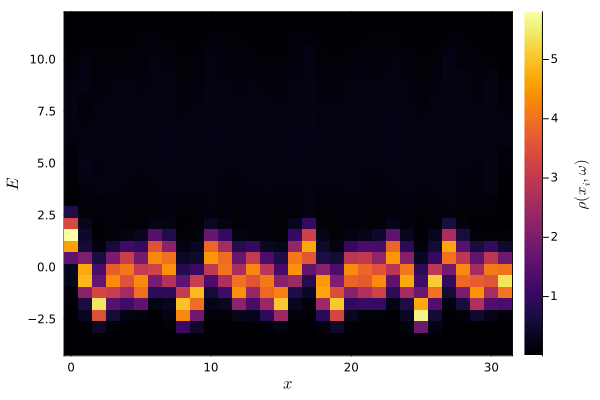

In [45]:
xvals = range(0, (N - 1); length=num_x)

plots = 
    heatmap(
      xvals, E,           # x and y axes
      ldos_sample;        # the i-th LDOS matrix
      xlabel            = L"x",
      ylabel            = L"E",
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
    #   cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         = L"\rho(x_i,\omega)" ,
      cbar_titlefontsize = 12
    )

## Example 2: 2D quasiperiodic incommensurate super-moiré potential

#### Hamiltonian construction

In [26]:
# parameters
Lx, Ly = 3, 3 # total number of physical sites in x and y directions
Nx, Ny = 2^Lx, 2^Ly
L = Lx + Ly
N  = 2^L
t = -0.5
on_site = 3.0
U0 = 6.0

wrap2D(f, Nx) = i -> f((i % Nx), (i ÷ Nx))

U(x,y) = U0

# --- 8-fold modulation term on the 2D coordinates
function func8fold(x, y, V;  Nx=Nx)
    # 4 vectors: (2π/a) * e_x, e_y, and their 45° rotation
    a = 1          # lattice constant for 8-fold modulation

    b1 = (5*sqrt(5)*a/2) # atomic scale wavevector
    b2 = (sqrt(3)*(Nx*a/16))  # superlattice scale wavevector

    Ka1 = 2π .* ( [1.0, 0.0] )
    Kb1 = 2π .* ( [0.0, 1.0] )
    tht   = deg2rad(45.0)
    Rt  = [cos(tht)  sin(tht);
            -sin(tht) cos(tht)]
    Ka2 = Rt * Ka1
    Kb2 = Rt * Kb1
    K   = (Ka1, Kb1, Ka2, Kb2)
    xy  = [x - Nx/2, y - Nx/2] # the offset is to obtain a nice symmetric pattern (assumes Nx=Ny)
    
    cosines = 0.0
    for k in K
        cosines += (1.5*cos(dot(k, xy)/b1) + 0.5*cos(dot(k, xy)/b2)) 
    end
    return V * (1 + 0.1 * cosines)
    # return V 

end

v_os = wrap2D((x, y) -> func8fold(x, y, on_site;  Nx=Nx), Nx)
u =  wrap2D((x, y) -> U(x,y), Nx)

HexcMPO = exciton_builders.Exciton_2D(Lx, Ly, u, t, v_os; tol_quantics=1e-8, maxbonddim_quantics=100, cutoff=1e-8, maxbonddim_gen=200);

#### Calculation of LDOS at $E=E_X$

In [27]:
ev, Nmu = 20, 50
E = range(-8,15, ev) #Energy range for the density calculation
# Normalized energy
e  = 0.2                      # small “epsilon” to avoid exactly eigs at ±1
W2 = (maximum(E) - minimum(E)) / 2   # half‐width of the energy range
a  = (maximum(E) + minimum(E)) / 2   # center of the energy range

# Shift & rescale so Ĥ ≈ (H - a I)/(W2 + e) has spectrum in [-1, 1]

sites = getindex.(siteinds(HexcMPO), 2)
Id_op = MPO(sites, "Id")
Ham_n = (HexcMPO - a*Id_op) / (W2 + e);

In [28]:
x_sample = 0:N-1

ldosv_e= zeros(Float64, N)

e=-2 # energy value for which we want to compute the LDOS
e_norm = (e - a) / (W2) 
e_norm = e_norm / (1 + e)  # normalized in [−1+ erra, 1 - errb]

@showprogress for x in 1:length(x_sample)
    mun = ExcitonKPM.ldos_exc_KPM_Tn(Ham_n, Nmu, x_sample[x]; cutoff=1e-12, maxdim=250)
    ldosv_e[x] = ExcitonKPM.get_ldos_from_mun(mun,Nmu,e_norm)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:06:46


#### Plotting results

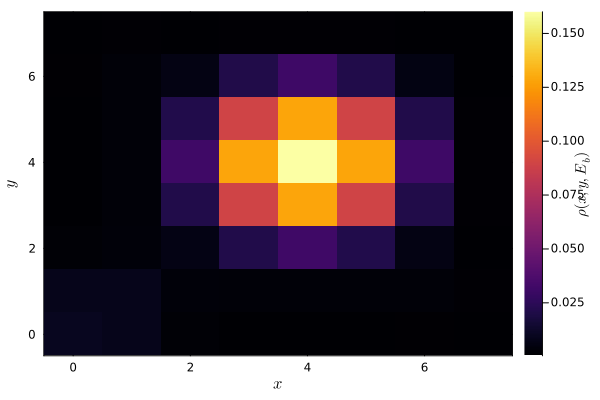

In [ ]:
xvals = range(0, (Nx - 1); length=Nx)
yvals = range(0, (Ny - 1); length=Ny)

ldos_e = reshape(ldosv_e, Ny, Nx)'

plots = 
    heatmap(
      xvals, yvals,           # x and y axes
      ldos_e;        # the i-th LDOS matrix
      xlabel            = L"x",
      ylabel            = L"y",
      color             = :inferno,
      aspect_ratio      = :auto,
      xflip             = false,
      yflip             = false,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
    #   cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         = L"\rho(x,y, E_b)",
      cbar_titlefontsize = 12
    )